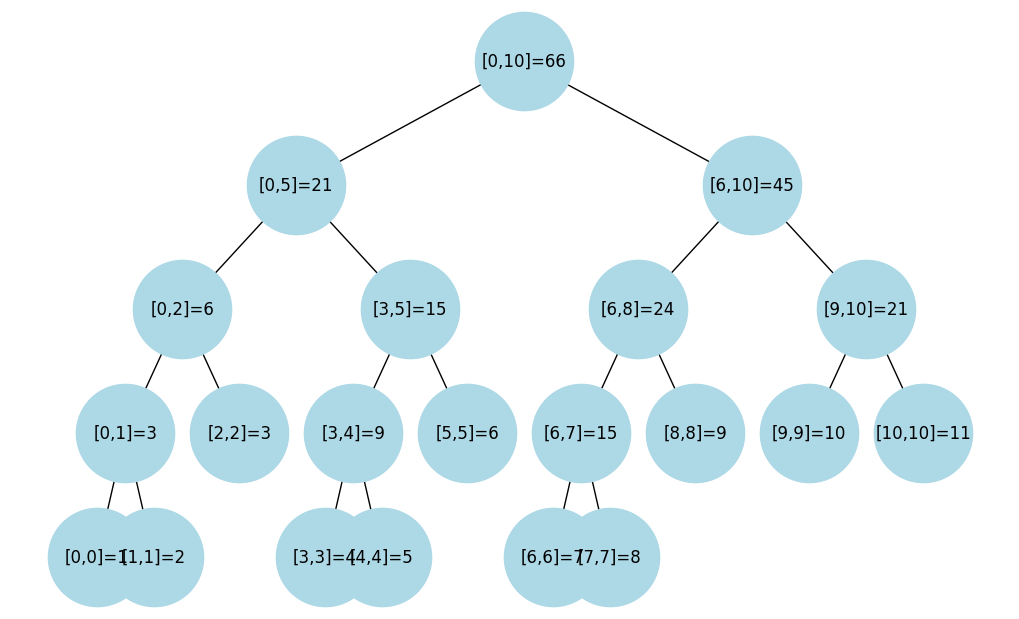

In [9]:
import matplotlib.pyplot as plt
import networkx as nx

class SegmentTree:
    def __init__(self, arr):
        self.arr = arr
        self.n = len(arr)
        self.seg = [0] * (4 * self.n)
        self.graph = nx.DiGraph()
        self.build(0, self.n - 1, 0)

    def build(self, start, end, node):
        if start == end:
            self.seg[node] = self.arr[start]
            label = f"[{start},{end}]={self.seg[node]}"
            self.graph.add_node(node, label=label)
            return

        mid = start + (end - start) // 2
        left, right = 2 * node + 1, 2 * node + 2
        self.build(start, mid, left)
        self.build(mid + 1, end, right)

        self.seg[node] = self.seg[left] + self.seg[right]
        label = f"[{start},{end}]={self.seg[node]}"
        self.graph.add_node(node, label=label)
        self.graph.add_edge(node, left)
        self.graph.add_edge(node, right)

    def _hierarchy_pos(self, G, root=0, width=1., vert_gap=0.2, vert_loc=0, xcenter=0.5):
        """
        Recursively compute positions for a tree layout.
        """
        pos = {root: (xcenter, vert_loc)}
        children = list(G.successors(root))
        if len(children) != 0:
            dx = width / len(children)
            nextx = xcenter - width / 2 - dx / 2
            for child in children:
                nextx += dx
                pos.update(self._hierarchy_pos(G, child, width=dx, vert_gap=vert_gap,
                                               vert_loc=vert_loc - vert_gap, xcenter=nextx))
        return pos

    def visualize(self):
        pos = self._hierarchy_pos(self.graph, 0)
        labels = nx.get_node_attributes(self.graph, 'label')
        plt.figure(figsize=(10, 6))
        nx.draw(self.graph, pos, with_labels=False, arrows=False,
                node_size=5000, node_color="lightblue", font_size=8)
        nx.draw_networkx_labels(self.graph, pos, labels)
        plt.show()


# Example usage
arr = [1, 2, 3, 4, 5, 6, 7, 8 , 9 , 10 , 11]
st = SegmentTree(arr)
st.visualize()


In [2]:
import matplotlib.pyplot as plt
import networkx as nx
from IPython.display import clear_output
import time

class LazySegmentTree:
    def __init__(self, arr):
        self.n = len(arr)
        self.seg = [0] * (4 * self.n)
        self.lazy = [0] * (4 * self.n)
        self.arr = arr
        self.build(0, 0, self.n - 1)

    def build(self, node, start, end):
        if start == end:
            self.seg[node] = self.arr[start]
            return
        mid = (start + end) // 2
        self.build(2*node+1, start, mid)
        self.build(2*node+2, mid+1, end)
        self.seg[node] = self.seg[2*node+1] + self.seg[2*node+2]

    def propagate(self, node, start, end):
        if self.lazy[node] != 0:
            self.seg[node] += (end - start + 1) * self.lazy[node]
            if start != end:
                self.lazy[2*node+1] += self.lazy[node]
                self.lazy[2*node+2] += self.lazy[node]
            self.lazy[node] = 0

    def update(self, l, r, val, node=0, start=0, end=None, animate=False):
        if end is None:
            end = self.n - 1
        self.propagate(node, start, end)

        # no overlap
        if r < start or l > end:
            return
        # full overlap
        if l <= start and end <= r:
            self.seg[node] += (end - start + 1) * val
            if start != end:
                self.lazy[2*node+1] += val
                self.lazy[2*node+2] += val
            if animate: self.visualize(node, start, end, action=f"Update [{l},{r}] += {val}")
            return
        # partial overlap
        mid = (start + end) // 2
        self.update(l, r, val, 2*node+1, start, mid, animate)
        self.update(l, r, val, 2*node+2, mid+1, end, animate)
        self.seg[node] = self.seg[2*node+1] + self.seg[2*node+2]
        if animate: self.visualize(node, start, end, action=f"Update [{l},{r}] += {val}")

    def query(self, l, r, node=0, start=0, end=None, animate=False):
        if end is None:
            end = self.n - 1
        self.propagate(node, start, end)

        if r < start or l > end: return 0
        if l <= start and end <= r:
            if animate: self.visualize(node, start, end, action=f"Query [{l},{r}]")
            return self.seg[node]

        mid = (start + end) // 2
        left_sum = self.query(l, r, 2*node+1, start, mid, animate)
        right_sum = self.query(l, r, 2*node+2, mid+1, end, animate)
        return left_sum + right_sum

    def visualize(self, highlight_node=None, start=None, end=None, action=""):
        """ Draw segment tree with node and lazy values """
        G = nx.Graph()
        pos = {}

        def build_graph(node, l, r, x=0, y=0, dx=1.5):
            pos[node] = (x, y)
            if l != r:
                mid = (l + r) // 2
                left, right = 2*node+1, 2*node+2
                G.add_edge(node, left)
                G.add_edge(node, right)
                build_graph(left, l, mid, x - dx, y - 1, dx/1.5)
                build_graph(right, mid+1, r, x + dx, y - 1, dx/1.5)

        build_graph(0, 0, self.n-1)

        plt.figure(figsize=(12,6))
        nx.draw(G, pos, with_labels=False, node_size=2000, node_color="lightblue")

        labels = {i: f"seg={self.seg[i]}\nlazy={self.lazy[i]}" for i in pos}
        nx.draw_networkx_labels(G, pos, labels)

        if highlight_node is not None:
            nx.draw_networkx_nodes(G, pos, nodelist=[highlight_node], node_color="orange")

        plt.title(f"Segment Tree Action: {action}", fontsize=14)
        plt.axis("off")
        plt.show()
        time.sleep(1)
        clear_output(wait=True)

# Example usage
arr = [1, 2, 3, 4, 5]
tree = LazySegmentTree(arr)

# Build visualization
tree.visualize(action="Initial Build")

# Animate update
tree.update(1, 3, 2, animate=True)

# Animate query
print("Query result:", tree.query(2, 4, animate=True))


Query result: 16
